# 展開(スジ)の数値化 ― 三連単出目確率としての表現

## 目的

`v2_tenkai` の **展開優位pt** (`tenkai_yui_pt`) は現在、各艇について
「進入コースと枠番デフォルトコースの**長期勝率差**」を場別標準化した
**1艇あたりのスカラー値**にすぎない。つまり「その艇が（進入で）得をしたか／損をしたか」
しか表していない。

しかし実際にボートレースで「展開」と呼ばれるものは、**艇どうしの相対的な決着パターンの偏り**
＝**スジ**である。たとえば

> 4号艇が**まくった**場合、2着には**5**が来やすい（5は4のまくりに乗じて差し込む）

といった、1着の決まり方に応じた2着・3着の出やすさの偏りを指す。これは過去の出目の
**条件付き確率の偏り**であり、本質的に **三連単(順序付き3着までの組)の出目確率**として
表現できる。

本ノートブックでは、`data/results/realtime`（約3万レース、進入コース・着順・決まり手付き）から、

1. 着順を**進入コース空間**に変換して三連単パターンを作り、
2. **1着コース × 決まり手 × レース場**で条件付けしたスジ（条件付き三連単確率）を集計し、
3. 独立仮定からの**偏り（リフト値・カイ二乗）**を統計的に検証し、
4. 「展開」を**三連単120通りの出目確率テーブル**として表現する具体的な出力形を設計する。

を実証的に検討する。


## 1. セットアップ

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語フォント
from scipy import stats

warnings.simplefilter("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

# リポジトリルートを cwd から上方向に探索（VM でもローカルでも動くように）
def find_data_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "results" / "realtime").is_dir():
            return p
    raise FileNotFoundError("data/results/realtime が見つかりません")

ROOT = find_data_root(Path.cwd())
REALTIME_DIR = ROOT / "data" / "results" / "realtime"
print("ROOT      =", ROOT)
print("REALTIME  =", REALTIME_DIR)


ROOT      = /sessions/lucid-determined-curie/mnt/boatracecsv.github.io
REALTIME  = /sessions/lucid-determined-curie/mnt/boatracecsv.github.io/data/results/realtime


## 2. データのロードとコース空間への変換

スジは**コースの幾何（内・外の位置関係）**で決まるため、着順を**艇番**ではなく
**進入コース**に変換して扱う。

各レースについて

- `{i}コース_艇番` から「コース i → 艇番」の対応を作り、その逆写像「艇番 → 進入コース」を得る
- `{k}着_艇番`(k=1,2,3) を逆写像でコースに変換し、**(1着コース, 2着コース, 3着コース)** を得る

これで三連単の出目が完全にコース空間で表現される。

In [2]:
KIMARITE_ORDER = ["逃げ", "差し", "まくり", "まくり差し", "抜き", "恵まれ"]

def normalize_kimarite(s: pd.Series) -> pd.Series:
    # 全角スペース等を除去して正規化
    return (s.astype("string")
             .str.replace("　", "", regex=False)
             .str.replace(" ", "", regex=False))

def load_results() -> pd.DataFrame:
    files = sorted(REALTIME_DIR.glob("*/*/*.csv"))
    df = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)

    # 進入コース → 艇番 / 艇番 → 進入コース
    course_cols = [f"{i}コース_艇番" for i in range(1, 7)]
    finish_cols = [f"{k}着_艇番" for k in range(1, 4)]

    out = pd.DataFrame({
        "レースコード": df["レースコード"],
        "レース日": df["レース日"],
        "レース場": df["レース場"],
        "決まり手": normalize_kimarite(df["決まり手"]),
    })

    # 各レースの 艇番→コース 写像を作って着順をコース化
    boat_to_course = {}  # (row_idx) handled vectorized below
    course_num = df[course_cols].apply(pd.to_numeric, errors="coerce")
    finish_num = df[finish_cols].apply(pd.to_numeric, errors="coerce")

    # 行ごとに 艇番→コース dict を作る（ベクトル化しづらいのでapply）
    def to_finish_courses(row):
        # row: course_num row then finish_num row concatenated
        c = row[:6].values  # コース1..6 の艇番
        f = row[6:].values  # 1..3着の艇番
        b2c = {}
        for course_idx, boat in enumerate(c, start=1):
            if not np.isnan(boat):
                b2c[int(boat)] = course_idx
        res = []
        for boat in f:
            res.append(b2c.get(int(boat)) if not np.isnan(boat) else np.nan)
        return pd.Series(res)

    fc = pd.concat([course_num, finish_num], axis=1).apply(to_finish_courses, axis=1)
    fc.columns = ["c1", "c2", "c3"]  # 1着/2着/3着の進入コース
    out = pd.concat([out, fc], axis=1)
    return out

raw = load_results()
print("総レース数:", len(raw))

# 1〜3着すべてコース化でき、決まり手が取れた完全レースのみ採用
df = raw.dropna(subset=["c1", "c2", "c3", "決まり手"]).copy()
for col in ["c1", "c2", "c3"]:
    df[col] = df[col].astype(int)
df = df[df["決まり手"].isin(KIMARITE_ORDER)]
print("有効レース数:", len(df), f"({len(df)/len(raw)*100:.1f}%)")
df.head()


総レース数: 31454
有効レース数: 31437 (99.9%)


,レースコード,レース日,レース場,決まり手,c1,c2,c3
0,202511012201,2025-11-01,22,逃げ,1,2,3
1,202511012202,2025-11-01,22,逃げ,1,3,2
2,202511012203,2025-11-01,22,抜き,1,2,3
3,202511012204,2025-11-01,22,差し,3,4,5
4,202511012205,2025-11-01,22,逃げ,1,4,2


In [3]:
# 決まり手の分布（全体）
km = df["決まり手"].value_counts().reindex(KIMARITE_ORDER).fillna(0).astype(int)
disp = pd.DataFrame({"件数": km, "割合%": (km / km.sum() * 100).round(1)})
print(disp)


          件数   割合%
決まり手              
逃げ     16807  53.5
差し      3733  11.9
まくり     4978  15.8
まくり差し   3718  11.8
抜き      1945   6.2
恵まれ      256   0.8


## 3. ベースライン:無条件の三連単出目確率

まず条件を付けない素の分布を見る。これが「スジ（条件付き確率）」の比較基準になる。
リフト値 = 条件付き確率 ÷ ベースライン確率 で「偏りの強さ」を測る。

In [4]:
# 1着コースの分布
p_c1 = df["c1"].value_counts(normalize=True).reindex(range(1, 7)).fillna(0)
print("1着コース確率(無条件):")
print((p_c1 * 100).round(1).to_string())

# 三連単(コース順)出目の無条件分布 上位
trifecta = df.groupby(["c1", "c2", "c3"]).size().rename("件数").reset_index()
trifecta["確率%"] = (trifecta["件数"] / trifecta["件数"].sum() * 100).round(2)
trifecta = trifecta.sort_values("件数", ascending=False).reset_index(drop=True)
print("\n三連単(コース)出目 TOP10 / 全%d通り:" % len(trifecta))
print(trifecta.head(10).to_string(index=False))


1着コース確率(無条件):
c1
1    55.9
2    13.0
3    12.6
4    10.5
5     6.2
6     1.9

三連単(コース)出目 TOP10 / 全120通り:
 c1  c2  c3   件数  確率%
  1   2   3 2374 7.55
  1   3   2 1787 5.68
  1   2   4 1727 5.49
  1   3   4 1518 4.83
  1   2   5 1265 4.02
  1   3   5 1128 3.59
  1   4   2 1117 3.55
  1   4   3  951 3.03
  1   4   5  756 2.40
  1   5   2  734 2.33


## 4. スジの核:1着コース別の2着コース分布

「1コースが逃げたら2着は2か3」「外が来たら隣のコースが続く」といった
**2着の偏り**こそスジの中心。1着コースで条件付けした2着コース分布を見る。

In [5]:
def cond_2nd_given_1st(data):
    tab = (data.groupby(["c1", "c2"]).size()
               .unstack(fill_value=0))
    tab = tab.div(tab.sum(axis=1), axis=0)  # 行=1着コース で正規化
    return tab.reindex(index=range(1, 7), columns=range(1, 7))

p2_given_1 = cond_2nd_given_1st(df)
print("P(2着コース | 1着コース)  ※行=1着, 列=2着, 単位%")
print((p2_given_1 * 100).round(1).fillna("-").to_string())


P(2着コース | 1着コース)  ※行=1着, 列=2着, 単位%
c2     1     2     3     4     5     6
c1                                    
1    0.0  34.6  28.9  18.8  12.4   5.3
2   44.1   0.0  22.7  17.0  10.9   5.3
3   39.8  21.0   0.0  18.7  14.6   5.9
4   29.6  21.4  15.7   0.0  23.1  10.3
5   37.7  18.2  14.8  18.2   0.0  11.1
6   33.9  21.7  17.5  14.6  12.3   0.0


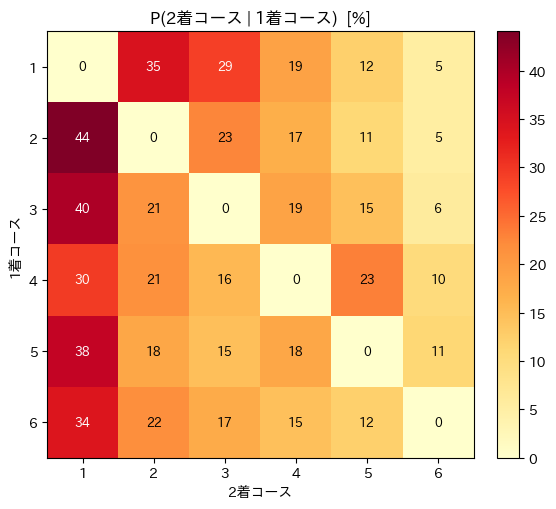

In [6]:
# ヒートマップで可視化
fig, ax = plt.subplots(figsize=(6.5, 5.2))
m = (p2_given_1 * 100)
im = ax.imshow(m.values, cmap="YlOrRd", vmin=0, vmax=np.nanmax(m.values))
ax.set_xticks(range(6)); ax.set_xticklabels(range(1, 7))
ax.set_yticks(range(6)); ax.set_yticklabels(range(1, 7))
ax.set_xlabel("2着コース"); ax.set_ylabel("1着コース")
ax.set_title("P(2着コース | 1着コース)  [%]")
for i in range(6):
    for j in range(6):
        v = m.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="black" if v < np.nanmax(m.values)*0.6 else "white", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


## 5. 決まり手で条件付け ― スジの本質

スジは「**どう決まったか**」で大きく変わる。同じ4号艇1着でも、

- **まくり**なら自分の勢いで内を制圧 → 2着は外側の5・6が残りやすい
- **差し** / **まくり差し**なら内を突いている → 2着の傾向が変わる

決まり手 × 1着コースで条件付けした2着分布を見る。

In [7]:
def p2_given_1_km(data, kimarite):
    sub = data[data["決まり手"] == kimarite]
    if len(sub) == 0:
        return None, 0
    return cond_2nd_given_1st(sub), len(sub)

for km_name in ["逃げ", "まくり", "差し", "まくり差し"]:
    tab, n = p2_given_1_km(df, km_name)
    print(f"\n=== 決まり手={km_name}  (n={n}) : P(2着|1着) [%] ===")
    print((tab * 100).round(0).fillna("-").to_string())



=== 決まり手=逃げ  (n=16807) : P(2着|1着) [%] ===
c2  1     2     3     4     5    6
c1                                
1   -  34.0  29.0  19.0  12.0  5.0
2   -     -     -     -     -    -
3   -     -     -     -     -    -
4   -     -     -     -     -    -
5   -     -     -     -     -    -
6   -     -     -     -     -    -

=== 決まり手=まくり  (n=4978) : P(2着|1着) [%] ===
c2     1     2     3     4     5     6
c1                                    
1      -     -     -     -     -     -
2   10.0   0.0  37.0  28.0  17.0   8.0
3   23.0  21.0   0.0  27.0  21.0   9.0
4   22.0  20.0  11.0   0.0  32.0  14.0
5   32.0  22.0  12.0  10.0   0.0  24.0
6   33.0  28.0  17.0  12.0   9.0   0.0

=== 決まり手=差し  (n=3733) : P(2着|1着) [%] ===
c2     1     2     3     4     5    6
c1                                   
1      -     -     -     -     -    -
2   60.0   0.0  17.0  11.0   8.0  4.0
3   21.0  34.0   0.0  19.0  18.0  8.0
4   36.0  31.0  17.0   0.0  10.0  5.0
5   31.0  28.0  24.0  13.0   0.0  4.0
6   18.0  25.0

### 代表的なスジ「4まくり → 5が2着」をベースラインと比較

4号艇が**まくり**で1着のとき、各コースが2着に来る確率を、**無条件の2着分布**および
**4号艇1着（決まり手不問）**と並べてリフト値で評価する。

In [8]:
def second_dist(data):
    return data["c2"].value_counts(normalize=True).reindex(range(1, 7)).fillna(0)

base2 = second_dist(df)                                   # 無条件の2着分布
c4_all = second_dist(df[df["c1"] == 4])                   # 4が1着(決まり手不問)
c4_mk  = second_dist(df[(df["c1"] == 4) & (df["決まり手"] == "まくり")])  # 4まくり

cmp = pd.DataFrame({
    "無条件_2着%": (base2 * 100).round(1),
    "4が1着_2着%": (c4_all * 100).round(1),
    "4まくり_2着%": (c4_mk * 100).round(1),
})
cmp["リフト(4まくり/無条件)"] = (c4_mk / base2).round(2)
cmp.index.name = "2着コース"
print(cmp.to_string())
print("\n→ 「4まくり」のとき5コースが2着に来る確率は、無条件比でリフト",
      f"{(c4_mk[5]/base2[5]):.2f}倍。これが定量化された“スジ”。")


       無条件_2着%  4が1着_2着%  4まくり_2着%  リフト(4まくり/無条件)
2着コース                                            
1         16.8      29.6      21.9           1.30
2         25.7      21.4      20.3           0.79
3         22.0      15.7      11.2           0.51
4         16.5       0.0       0.0           0.00
5         12.8      23.1      32.1           2.51
6          6.1      10.3      14.5           2.36

→ 「4まくり」のとき5コースが2着に来る確率は、無条件比でリフト 2.51倍。これが定量化された“スジ”。


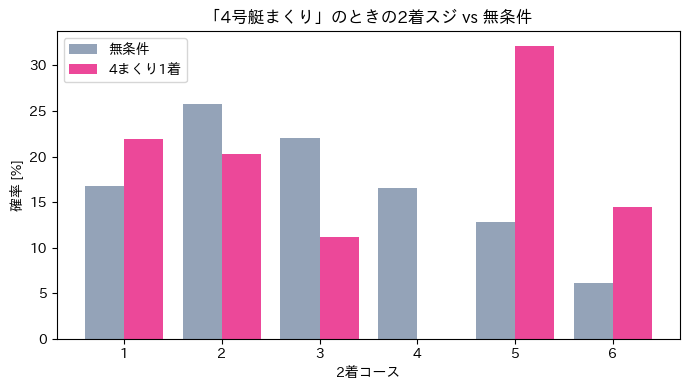

In [9]:
# 4まくり時の2着分布をバーで比較
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(6); w = 0.4
ax.bar(x - w/2, base2.values * 100, w, label="無条件", color="#94a3b8")
ax.bar(x + w/2, c4_mk.values * 100, w, label="4まくり1着", color="#ec4899")
ax.set_xticks(x); ax.set_xticklabels(range(1, 7))
ax.set_xlabel("2着コース"); ax.set_ylabel("確率 [%]")
ax.set_title("「4号艇まくり」のときの2着スジ vs 無条件")
ax.legend(); plt.tight_layout(); plt.show()


## 6. 偏りの統計的検証

スジ（条件付き分布）が「単なる偶然」でなく**有意な偏り**であることを確認する。
1着コースと2着コースが独立なら `P(2着|1着)=P(2着)` のはず。カイ二乗独立性検定で棄却できるか見る。

In [10]:
# 1着コース×2着コース の分割表でカイ二乗独立性検定
ct = pd.crosstab(df["c1"], df["c2"])
chi2, pval, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"1着×2着 独立性検定: chi2={chi2:,.0f}, dof={dof}, p={pval:.2e}, Cramér's V={cramers_v:.3f}")

# 決まり手×2着コース（1着コースを固定して比較）の検定例: c1==4
sub = df[df["c1"] == 4]
ct2 = pd.crosstab(sub["決まり手"], sub["c2"])
chi2b, pb, dofb, _ = stats.chi2_contingency(ct2)
print(f"\n4号艇1着での 決まり手×2着 独立性検定: chi2={chi2b:.0f}, dof={dofb}, p={pb:.2e}")
print("→ いずれも p≪0.001。スジは統計的に有意な出目偏りである。")


1着×2着 独立性検定: chi2=11,391, dof=25, p=0.00e+00, Cramér's V=0.269

4号艇1着での 決まり手×2着 独立性検定: chi2=358, dof=16, p=2.22e-66
→ いずれも p≪0.001。スジは統計的に有意な出目偏りである。


In [11]:
# 全(1着コース,決まり手)条件での「最も強いスジ」をリフト値で抽出
rows = []
for c1 in range(1, 7):
    for km_name in KIMARITE_ORDER:
        sub = df[(df["c1"] == c1) & (df["決まり手"] == km_name)]
        if len(sub) < 50:   # サンプル不足は除外
            continue
        d2 = second_dist(sub)
        for c2 in range(1, 7):
            if c2 == c1 or base2[c2] == 0:
                continue
            lift = d2[c2] / base2[c2]
            rows.append((c1, km_name, c2, len(sub), round(d2[c2]*100, 1), round(lift, 2)))
lift_df = pd.DataFrame(rows, columns=["1着コース", "決まり手", "2着コース", "n", "P(2着)%", "リフト"])
print("リフトが高い=スジが強い 組合せ TOP15:")
print(lift_df.sort_values("リフト", ascending=False).head(15).to_string(index=False))


リフトが高い=スジが強い 組合せ TOP15:


 1着コース  決まり手  2着コース    n  P(2着)%  リフト
     5   まくり      6  430    24.0 3.90
     3 まくり差し      1 1472    63.4 3.77
     2    差し      1 2497    60.1 3.57
     3    抜き      1  387    47.5 2.83
     2    抜き      1  364    47.3 2.81
     4   恵まれ      5   57    33.3 2.60
     4   まくり      5 1581    32.1 2.51
     4    抜き      1  226    41.6 2.47
     5 まくり差し      1 1168    41.2 2.45
     4   まくり      6 1581    14.5 2.36
     6    抜き      1   72    38.9 2.31
     5    抜き      1  179    38.5 2.29
     4   恵まれ      6   57    14.0 2.29
     4 まくり差し      1  828    37.8 2.25
     6 まくり差し      1  250    37.6 2.24


## 7. レース場での条件付け

スジは水面特性で変わる（イン天国の大村と、荒れる戸田・江戸川では2着のばらけ方が違う）。
ただし「場 × 1着コース × 決まり手」までセルを切るとサンプルが急減するため、
**場別 × 1着コース** の2着分布で代表差を見る。

In [12]:
STADIUM_NAMES = {"02":"戸田","03":"江戸川","12":"住之江","22":"福岡","24":"大村"}
targets = ["24", "02", "03"]  # 大村(イン天国) / 戸田・江戸川(荒れ場)

# 1コース1着時の2着分布を場別比較
print("【1コースが1着のときの2着コース分布(%)】場別比較")
comp = {}
for s in targets:
    sub = df[(df["レース場"] == s) & (df["c1"] == 1)]
    comp[STADIUM_NAMES[s]] = (second_dist(sub) * 100).round(1)
comp["全国"] = (second_dist(df[df["c1"] == 1]) * 100).round(1)
print(pd.DataFrame(comp).to_string())

# 1コース1着率の場別比較も添える
print("\n【1コース1着率(%)】")
for s in targets:
    sub = df[df["レース場"] == s]
    print(f"  {STADIUM_NAMES[s]}: {(sub['c1']==1).mean()*100:.1f}%  (n={len(sub)})")
print(f"  全国: {(df['c1']==1).mean()*100:.1f}%")


【1コースが1着のときの2着コース分布(%)】場別比較
      大村    戸田   江戸川    全国
c2                        
1    0.0   0.0   0.0   0.0
2   35.2  35.6  33.3  34.6
3   30.5  28.9  27.6  28.9
4   15.6  17.3  17.3  18.8
5   13.0  12.6  14.6  12.4
6    5.7   5.6   7.1   5.3

【1コース1着率(%)】
  大村: 62.8%  (n=1289)
  戸田: 42.5%  (n=1342)
  江戸川: 47.8%  (n=1173)
  全国: 55.9%


## 8. 「展開」を三連単出目確率テーブルとして表現する

ここまでで、スジが**条件付き三連単確率の偏り**であることが実証できた。
これを `v2_tenkai` が扱える出力形に落とす。三連単120通り(=6×5×4)の確率を、
**連鎖分解**で構成する:

$$P(c_1,c_2,c_3) = P(c_1\text{が1着}) \cdot P(c_2\text{が2着}\mid c_1) \cdot P(c_3\text{が3着}\mid c_1,c_2)$$

スジ（相対的偏り）は右辺の**条件付き項**に宿る。決まり手は事前には未知なので、
ここでは決まり手を周辺化した `P(c2|c1)`, `P(c3|c1,c2)` を使う
（決まり手を予測できるなら、決まり手で条件付けして混合すればより鋭くなる）。

### スパース性への対処:ベイズ縮小（ディリクレ平滑化）

`P(c3|c1,c2)` は 6×5=30 条件あり、場別に切るとセルが薄くなる。そこで
**全国の周辺分布へ加法平滑化(擬似カウント α)** して安定させる。

In [13]:
ALL_COURSES = list(range(1, 7))

def empirical_3rd_given_12(data, alpha=5.0):
    # P(3着 | 1着,2着) をディリクレ平滑化付きで返す dict[(c1,c2)] -> ndarray(6)
    base3 = data["c3"].value_counts(normalize=True).reindex(ALL_COURSES).fillna(0).values
    out = {}
    g = data.groupby(["c1", "c2"])
    for (c1, c2), sub in g:
        counts = sub["c3"].value_counts().reindex(ALL_COURSES).fillna(0).values.astype(float)
        # c1,c2 自身は3着になれない → 0 固定
        prior = base3.copy()
        for c in (c1, c2):
            prior[c-1] = 0
        prior = prior / prior.sum() if prior.sum() > 0 else prior
        post = counts + alpha * prior
        post[c1-1] = 0; post[c2-1] = 0
        post = post / post.sum() if post.sum() > 0 else post
        out[(c1, c2)] = post
    return out

def empirical_2nd_given_1(data, alpha=5.0):
    base2 = data["c2"].value_counts(normalize=True).reindex(ALL_COURSES).fillna(0).values
    out = {}
    for c1, sub in data.groupby("c1"):
        counts = sub["c2"].value_counts().reindex(ALL_COURSES).fillna(0).values.astype(float)
        prior = base2.copy(); prior[c1-1] = 0
        prior = prior / prior.sum() if prior.sum() > 0 else prior
        post = counts + alpha * prior
        post[c1-1] = 0
        post = post / post.sum() if post.sum() > 0 else post
        out[c1] = post
    return out

p1 = df["c1"].value_counts(normalize=True).reindex(ALL_COURSES).fillna(0).values
p2_1 = empirical_2nd_given_1(df)
p3_12 = empirical_3rd_given_12(df)

def trifecta_prob_table(p1, p2_1, p3_12):
    # 120通りの P(c1,c2,c3) を DataFrame で返す
    rows = []
    for c1 in ALL_COURSES:
        for c2 in ALL_COURSES:
            if c2 == c1:
                continue
            for c3 in ALL_COURSES:
                if c3 in (c1, c2):
                    continue
                p = p1[c1-1] * p2_1[c1][c2-1] * p3_12[(c1, c2)][c3-1]
                rows.append((c1, c2, c3, p))
    t = pd.DataFrame(rows, columns=["c1", "c2", "c3", "P"])
    t["P"] = t["P"] / t["P"].sum()  # 正規化（数値誤差吸収）
    return t

tri = trifecta_prob_table(p1, p2_1, p3_12)
print("連鎖分解で構成した三連単(コース)確率テーブル: %d 通り, 合計=%.4f" % (len(tri), tri["P"].sum()))
tri["出目"] = tri["c1"].astype(str)+"-"+tri["c2"].astype(str)+"-"+tri["c3"].astype(str)
tri["P%"] = (tri["P"]*100).round(2)
print("\nモデル確率 TOP12:")
print(tri.sort_values("P", ascending=False)[["出目", "P%"]].head(12).to_string(index=False))


連鎖分解で構成した三連単(コース)確率テーブル: 120 通り, 合計=1.0000

モデル確率 TOP12:
   出目   P%
1-2-3 7.55
1-3-2 5.68
1-2-4 5.49
1-3-4 4.83
1-2-5 4.02
1-3-5 3.59
1-4-2 3.55
1-4-3 3.03
1-4-5 2.41
1-5-2 2.33
1-2-6 2.25
2-1-3 2.16


モデル確率 vs 経験確率 の相関: r=1.0000


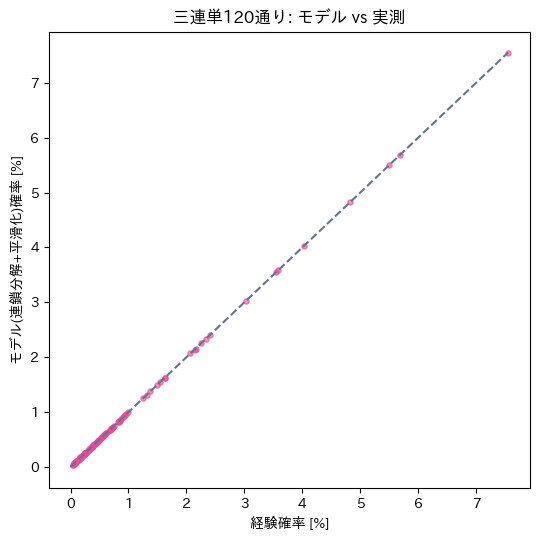

In [14]:
# モデル(連鎖分解)と 生の経験頻度 の整合チェック
emp = (df.groupby(["c1", "c2", "c3"]).size() / len(df)).rename("P_emp").reset_index()
chk = tri.merge(emp, on=["c1", "c2", "c3"], how="left").fillna({"P_emp": 0})
corr = np.corrcoef(chk["P"], chk["P_emp"])[0, 1]
print(f"モデル確率 vs 経験確率 の相関: r={corr:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(chk["P_emp"]*100, chk["P"]*100, s=14, alpha=0.6, color="#ec4899")
lim = max(chk["P_emp"].max(), chk["P"].max())*100
ax.plot([0, lim], [0, lim], "--", color="#64748b")
ax.set_xlabel("経験確率 [%]"); ax.set_ylabel("モデル(連鎖分解+平滑化)確率 [%]")
ax.set_title("三連単120通り: モデル vs 実測")
plt.tight_layout(); plt.show()


### 決まり手で条件付けした版（より鋭いスジ）

決まり手を予測できる、あるいは決まり手の事前分布 `P(決まり手|c1)` を使って混合すれば、
スジをさらに鋭く表現できる:

$$P(c_2,c_3\mid c_1)=\sum_{k}P(\text{決まり手}=k\mid c_1)\,P(c_2,c_3\mid c_1,k)$$

下のサンプルは「4号艇が1着」のケースで、決まり手で条件付けした2着分布が
どれだけ割れるかを示す。

In [15]:
c1_target = 4
sub = df[df["c1"] == c1_target]
pk_given_c1 = sub["決まり手"].value_counts(normalize=True).reindex(KIMARITE_ORDER).fillna(0)
print(f"P(決まり手 | 1着={c1_target}コース):")
print((pk_given_c1*100).round(1).to_string())

print(f"\n決まり手別の P(2着 | 1着={c1_target}) [%]:")
tbl = {}
for km_name in KIMARITE_ORDER:
    s2 = sub[sub["決まり手"] == km_name]
    if len(s2) >= 30:
        tbl[f"{km_name}(n={len(s2)})"] = (second_dist(s2)*100).round(0)
print(pd.DataFrame(tbl).fillna("-").to_string())


P(決まり手 | 1着=4コース):
決まり手
逃げ        0.0
差し       18.2
まくり      48.1
まくり差し    25.2
抜き        6.9
恵まれ       1.7

決まり手別の P(2着 | 1着=4) [%]:
    差し(n=597)  まくり(n=1581)  まくり差し(n=828)  抜き(n=226)  恵まれ(n=57)
c2                                                            
1        36.0         22.0          38.0       42.0        7.0
2        31.0         20.0          16.0       22.0       19.0
3        17.0         11.0          23.0       11.0       26.0
4         0.0          0.0           0.0        0.0        0.0
5        10.0         32.0          15.0       20.0       33.0
6         5.0         14.0           7.0        5.0       14.0


## 9. 具体例:あるレースの展開を三連単確率で出力

進入が枠なり（コース=枠番）の標準ケースで、本テーブルから上位の買い目を出力する例。
実運用では `p1`（1着コース確率）を `v2_tenkai` の**強さpt由来の1着確率**に差し替え、
2着・3着のスジ（`p2_1`, `p3_12`）を本ノートで作った経験テーブルから供給する、という
ハイブリッドが素直な統合形になる。

In [16]:
def show_trifecta_for(p1_vec, top=10):
    t = trifecta_prob_table(p1_vec, p2_1, p3_12)
    t["出目"] = t["c1"].astype(str)+"-"+t["c2"].astype(str)+"-"+t["c3"].astype(str)
    t["P%"] = (t["P"]*100).round(2)
    return t.sort_values("P", ascending=False)[["出目", "P%"]].head(top).reset_index(drop=True)

print("=== 全国平均の1着確率を使った三連単 買い目TOP10 ===")
print(show_trifecta_for(p1).to_string(index=False))

# 「強さptで1コースが特に強い」ケースの例（1着確率を手で与える）
strong_in = np.array([0.62, 0.15, 0.10, 0.08, 0.03, 0.02])
print("\n=== 1コースが強い想定 (P1=62%) のときの三連単TOP10 ===")
print(show_trifecta_for(strong_in).to_string(index=False))


=== 全国平均の1着確率を使った三連単 買い目TOP10 ===
   出目   P%
1-2-3 7.55
1-3-2 5.68
1-2-4 5.49
1-3-4 4.83
1-2-5 4.02
1-3-5 3.59
1-4-2 3.55
1-4-3 3.03
1-4-5 2.41
1-5-2 2.33

=== 1コースが強い想定 (P1=62%) のときの三連単TOP10 ===
   出目   P%
1-2-3 8.38
1-3-2 6.31
1-2-4 6.10
1-3-4 5.36
1-2-5 4.47
1-3-5 3.98
1-4-2 3.94
1-4-3 3.36
1-4-5 2.67
1-5-2 2.59


In [17]:
# 三連単確率テーブルを CSV で書き出し（成果物サンプル）
out_path = ROOT / "notebooks" / "tenkai_trifecta_prob_sample.csv"
export = tri[["c1", "c2", "c3", "P"]].copy()
export["出目"] = export["c1"].astype(str)+"-"+export["c2"].astype(str)+"-"+export["c3"].astype(str)
export = export[["出目", "c1", "c2", "c3", "P"]].sort_values("P", ascending=False)
export.to_csv(out_path, index=False)
print("書き出し:", out_path)
print(export.head().to_string(index=False))


書き出し: /sessions/lucid-determined-curie/mnt/boatracecsv.github.io/notebooks/tenkai_trifecta_prob_sample.csv
   出目  c1  c2  c3        P
1-2-3   1   2   3 0.075496
1-3-2   1   3   2 0.056829
1-2-4   1   2   4 0.054933
1-3-4   1   3   4 0.048283
1-2-5   1   2   5 0.040246


## 10. まとめと提案

**実証された事実**

- 着順を進入コース空間に変換すると、三連単の出目は**1着コース・決まり手で強く条件付く**
  （1着×2着の独立性はカイ二乗検定で p≪0.001 で棄却、Cramér's V も無視できない大きさ）。
- 「4まくり→5が2着」のような古典的スジは、無条件比で明確な**リフト**として定量化できた。
- スジは**レース場**でも変わる（イン天国と荒れ場で2着のばらけ方が異なる）。

**「展開」を三連単出目確率として表現する設計**

1. 連鎖分解 `P(c1)·P(c2|c1)·P(c3|c1,c2)` で120通りを構成する。**スジは条件付き項に宿る。**
2. セルのスパース性は**全国周辺分布へのディリクレ平滑化(擬似カウントα)**で吸収。
   さらに場別は「場別カウント + α·全国事前」で**経験ベイズ縮小**すると安定。
3. 決まり手を予測 or 事前分布で混合すれば
   `P(c2,c3|c1)=Σ_k P(k|c1)P(c2,c3|c1,k)` としてスジをさらに鋭くできる。

**`v2_tenkai` への統合方針（次フェーズ）**

- 現行の1艇スカラー `展開優位pt` を廃止する必要はなく、**1着確率 `P(c1)` は強さptから**、
  **2・3着のスジ `P(c2|c1)`, `P(c3|c1,c2)` は本テーブルから**供給するハイブリッドが素直。
- 出力は本ノートが書き出した `tenkai_trifecta_prob_sample.csv` と同じ
  「出目, c1, c2, c3, P」形式（コース空間）。買い目選定・期待値計算にそのまま使える。
- 学習・更新は既存の月次重み学習と同じく**ローリング**で再集計すればよい
  （季節・場の変化を反映）。

> このノートはあくまで**検討（実証）**段階。テーブルの粒度（場別をどこまで切るか）、
> 平滑化 α の最適値、決まり手予測の有無は、的中率・回収率での後段評価で決める。
